In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
pd.set_option('display.max_colwidth', None)

In [ ]:
data = pd.read_csv("construction_estimates.csv")
data.head()

,Material_Cost,Labor_Cost,Profit_Rate,Discount_or_Markup,Policy_Reason,Total_Estimate
0,43985,12836,10,1095,Market conditions require competitive pricing for this project.,63598.10
1,45504,17873,15,-6426,Market conditions require competitive pricing for this project.,66457.55
2,33656,8401,25,9862,"The client is a repeat customer, deserving a loyalty discount.",62433.25
3,36509,8523,20,8096,"The client is a repeat customer, deserving a loyalty discount.",62134.40
4,37372,14123,30,-9598,Strategic importance of this client justifies special pricing.,57345.50


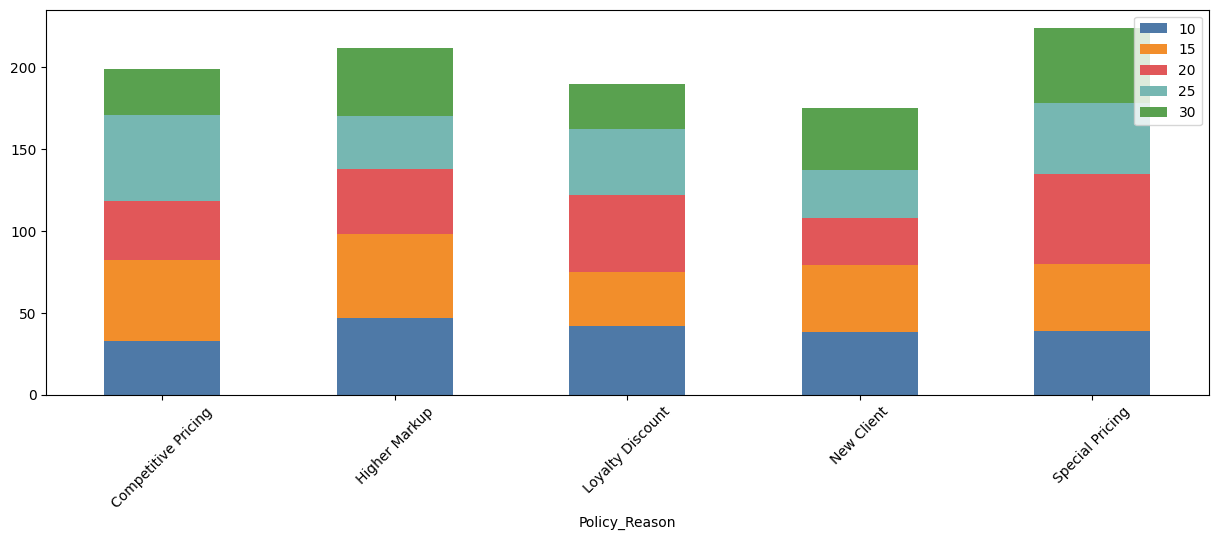

In [ ]:
policy = ['Competitive Pricing', 'Loyalty Discount', 'Special Pricing', 'Higher Markup', 'New Client']
policy_reason =  data['Policy_Reason'].unique()

for i in  range(5):
  data.loc[data['Policy_Reason'] == policy_reason[i], 'Policy_Reason'] = policy[i]

colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']
fig, ax = plt.subplots(figsize = (15,5))
pr_pr = pd.crosstab(data['Policy_Reason'], data['Profit_Rate'])
pr_pr.plot(kind = 'bar', stacked = True, color = colors, ax = ax)
plt.xticks(rotation=45)
plt.legend(loc = 'upper right')
plt.show()

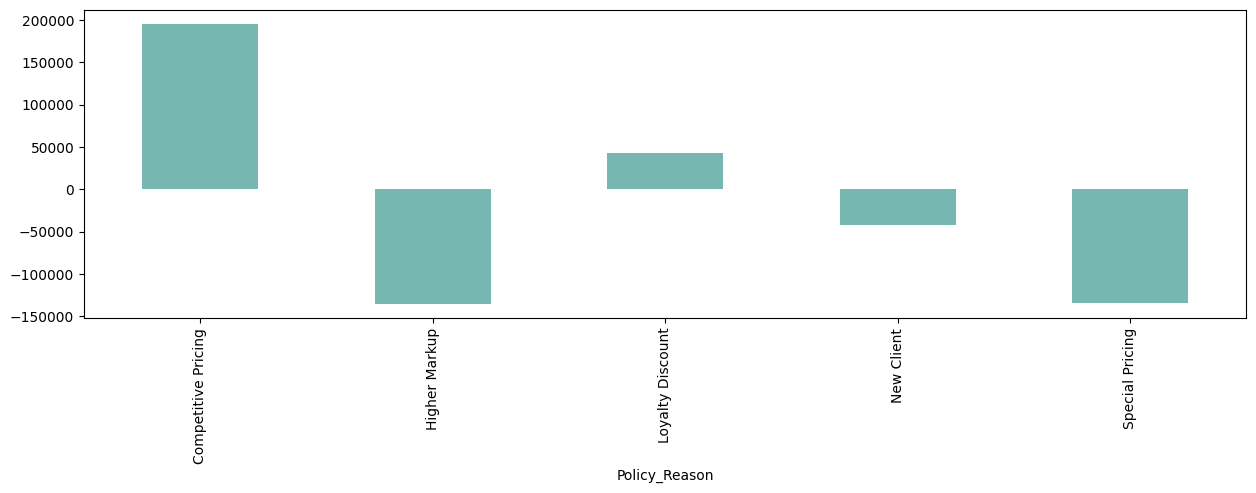

In [ ]:
pr_dm = data.groupby(['Policy_Reason'])['Discount_or_Markup'].sum()
fig, ax = plt.subplots(figsize = (15, 4))
pr_dm.plot(kind = 'bar',color = '#76B7B2', ax = ax)
plt.show()

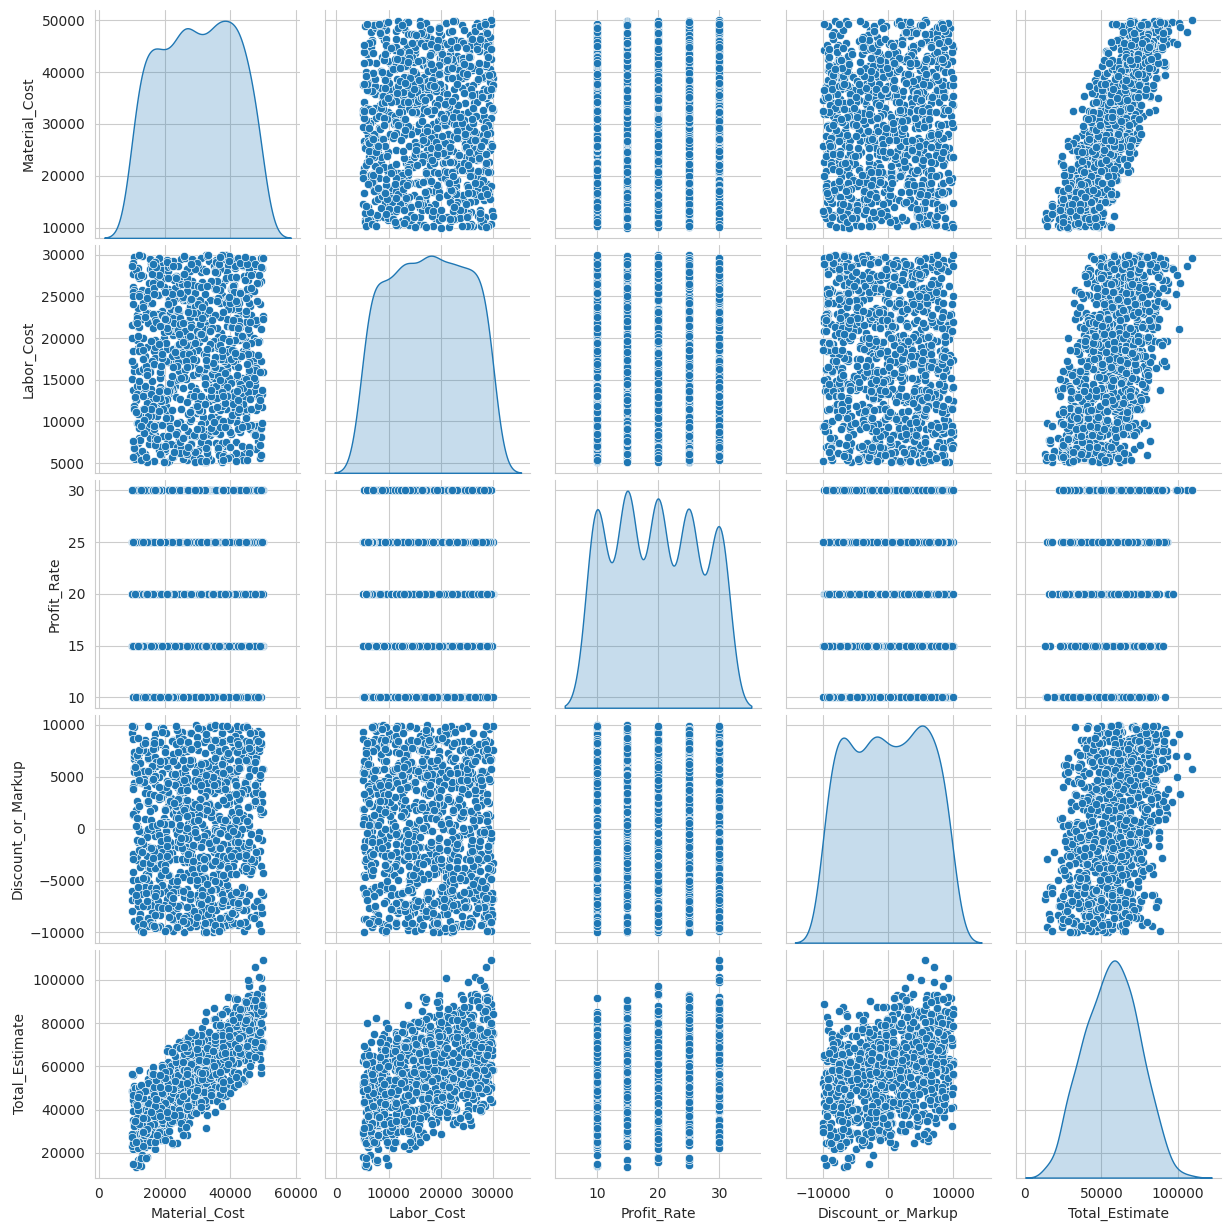

In [ ]:
sns.set_style("whitegrid")

sns.pairplot(data,diag_kind="kde")

plt.show()

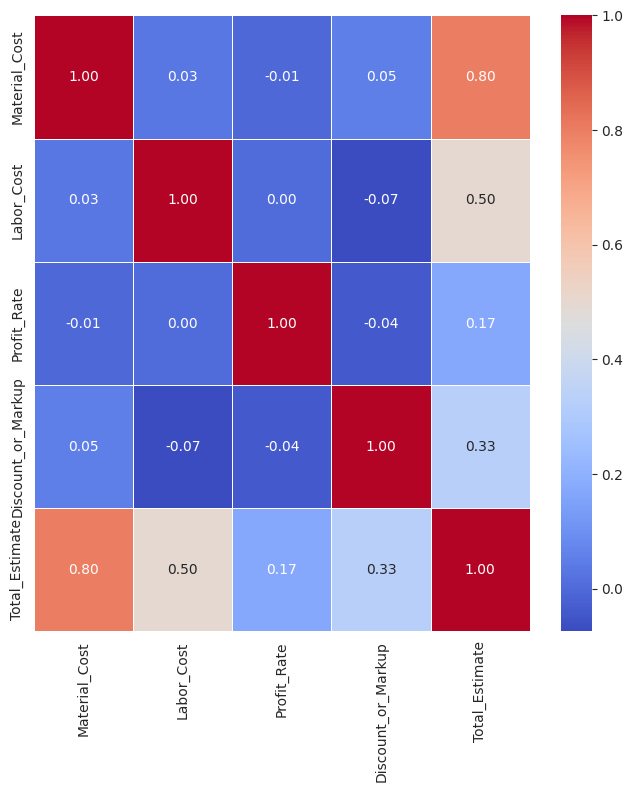

In [ ]:
correlation_matrix = data[['Material_Cost', 'Labor_Cost', 'Profit_Rate', 'Discount_or_Markup','Total_Estimate']].corr()
plt.figure(figsize = (8,8))
sns.heatmap(correlation_matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [ ]:
# Features and target
X = data.drop(columns='Total_Estimate')
y = data['Total_Estimate']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Feature groups
numerical_features = [
    'Material_Cost',
    'Labor_Cost',
    'Profit_Rate',
    'Discount_or_Markup'
]

categorical_features = ['Policy_Reason']

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Full pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Scores
print(f"Train R²: {r2_score(y_train, train_pred):.4f}")
print(f"Test R²:  {r2_score(y_test, test_pred):.4f}")

Train R²: 0.9971
Test R²:  0.9970


In [ ]:
scaler = model.named_steps['preprocessor'].named_transformers_['num']
scaled_coef_num = model.named_steps['regressor'].coef_[:len(numerical_features)]
coef_df_num =  scaled_coef_num / scaler.scale_
coef_num = pd.DataFrame({'Features': numerical_features, 'Coefficient': coef_df_num})


scaled_coef_cat = model.named_steps['regressor'].coef_[len(numerical_features):]
cat_column_name = model.named_steps['preprocessor'].get_feature_names_out()[len(numerical_features):]
coef_cat = pd.DataFrame({'Features': cat_column_name, 'Coefficient': scaled_coef_cat})

coef_dt = pd.concat([coef_num, coef_cat]).sort_values(by="Coefficient", key=abs, ascending=False).reset_index()
coef_dt = coef_dt.drop(columns = 'index')
coef_dt

,Features,Coefficient
0,Profit_Rate,476.651527
1,cat__Policy_Reason_New Client,71.243242
2,cat__Policy_Reason_Loyalty Discount,28.241240
3,cat__Policy_Reason_Special Pricing,-20.213762
4,cat__Policy_Reason_Higher Markup,14.325839
5,Material_Cost,1.192288
6,Labor_Cost,1.192167
7,Discount_or_Markup,0.995782


In [ ]:
import warnings
warnings.filterwarnings('ignore')

coef_dt['Interpretation'] = np.nan

for i, j in enumerate(coef_dt['Features']):

    feature = coef_dt.loc[i, 'Features']
    coef = round(coef_dt.loc[i, 'Coefficient'], 2)

    if 'cat' in j:
        policy = feature.replace('cat__Policy_', '')

        if coef_dt.loc[i, 'Coefficient'] > 0:
            coef_dt.loc[i, 'Interpretation'] = (
                f"Policy {policy} ↑ estimation cost by {coef} units"
            )
        else:
            coef_dt.loc[i, 'Interpretation'] = (
                f"Policy {policy} ↓ estimation cost by {abs(coef)} units"
            )

    else:
        if coef_dt.loc[i, 'Coefficient'] > 0:
            coef_dt.loc[i, 'Interpretation'] = (
                f"1 unit ↑ in {feature} ↑ estimation cost by {coef} units"
            )
        else:
            coef_dt.loc[i, 'Interpretation'] = (
                f"1 unit ↓ in {feature} ↓ estimation cost by {abs(coef)} units"
            )

In [ ]:
for i in range(len(coef_dt)):
  coef_dt.loc[i,'Features'] = coef_dt.loc[i,'Features'].replace('cat__', '')
coef_dt

,Features,Coefficient,Interpretation
0,Profit_Rate,476.651527,1 unit ↑ in Profit_Rate ↑ estimation cost by 476.65 units
1,Policy_Reason_New Client,71.243242,Policy Reason_New Client ↑ estimation cost by 71.24 units
2,Policy_Reason_Loyalty Discount,28.241240,Policy Reason_Loyalty Discount ↑ estimation cost by 28.24 units
3,Policy_Reason_Special Pricing,-20.213762,Policy Reason_Special Pricing ↓ estimation cost by 20.21 units
4,Policy_Reason_Higher Markup,14.325839,Policy Reason_Higher Markup ↑ estimation cost by 14.33 units
5,Material_Cost,1.192288,1 unit ↑ in Material_Cost ↑ estimation cost by 1.19 units
6,Labor_Cost,1.192167,1 unit ↑ in Labor_Cost ↑ estimation cost by 1.19 units
7,Discount_or_Markup,0.995782,1 unit ↑ in Discount_or_Markup ↑ estimation cost by 1.0 units
